In [1]:
import numpy as np 

import pandas as pd 

import scipy as sp 

from scipy import stats 

import matplotlib 

import sqlite3 

import matplotlib.pyplot as plt 

import seaborn as sns 

import sklearn 

from sklearn.preprocessing import StandardScaler 

from sklearn.decomposition import PCA 

import warnings 

import re 

warnings.filterwarnings('ignore') 

In [2]:
#upload the data file 

air_df = pd.read_csv('Air_Quality.csv') 

conn=sqlite3.connect('Air_Quality.csv') 

#check that it was uploaded 

air_df.head(n = 3) 

,Unique ID,Indicator ID,Name,Measure,Measure Info,Geo Type Name,Geo Join ID,Geo Place Name,Time Period,Start_Date,Data Value,Message
0,336867,375,Nitrogen dioxide (NO2),Mean,ppb,CD,407,Flushing and Whitestone (CD7),Winter 2014-15,12/01/2014,23.97,NaN
1,336741,375,Nitrogen dioxide (NO2),Mean,ppb,CD,107,Upper West Side (CD7),Winter 2014-15,12/01/2014,27.42,NaN
2,550157,375,Nitrogen dioxide (NO2),Mean,ppb,CD,414,Rockaway and Broad Channel (CD14),Annual Average 2017,01/01/2017,12.55,NaN


In [3]:
#check the column names 

air_df.columns 

Index(['Unique ID', 'Indicator ID', 'Name', 'Measure', 'Measure Info',
       'Geo Type Name', 'Geo Join ID', 'Geo Place Name', 'Time Period',
       'Start_Date', 'Data Value', 'Message'],
      dtype='object')

In [4]:
#Change data types 

air_df['Unique ID'].apply(int) 

air_df['Indicator ID'].apply(int) 

air_df['Name'].apply(str) 

air_df['Measure'].apply(str) 

air_df['Measure Info'].apply(str) 

air_df['Geo Type Name'].apply(str) 

air_df['Geo Join ID'].apply(int) 

air_df['Geo Place Name'].apply(str) 

air_df['Time Period'].apply(str) 

air_df['Start_Date'].apply(str) 

air_df['Data Value'].apply(float)

0        23.97
1        27.42
2        12.55
3        22.63
4        14.00
         ...  
18857    25.78
18858    28.13
18859    28.78
18860    23.68
18861    23.77
Name: Data Value, Length: 18862, dtype: float64

In [5]:
#look for invalid values 

invalidmask = air_df.astype(str).applymap(lambda x: bool(re.search(r'[^ -~]', x))) 

dirty_rows=air_df[invalidmask.any(axis=1)]
print(dirty_rows) 

       Unique ID  Indicator ID                               Name  \
7546      799850           647  Outdoor Air Toxics - Formaldehyde   
7547      315663           647  Outdoor Air Toxics - Formaldehyde   
7548      315673           647  Outdoor Air Toxics - Formaldehyde   
7549      130767           647  Outdoor Air Toxics - Formaldehyde   
7550      130739           647  Outdoor Air Toxics - Formaldehyde   
...          ...           ...                                ...   
18685     130764           647  Outdoor Air Toxics - Formaldehyde   
18686     799867           647  Outdoor Air Toxics - Formaldehyde   
18687     315641           647  Outdoor Air Toxics - Formaldehyde   
18777     130780           647  Outdoor Air Toxics - Formaldehyde   
18778     227527           647  Outdoor Air Toxics - Formaldehyde   

                            Measure Measure Info Geo Type Name  Geo Join ID  \
7546   Annual average concentration       Âµg/m3         UHF42          408   
7547   Annual

In [6]:
#drop duplicates & locate empty cells 

clean_df = air_df.drop_duplicates(subset= 

['Indicator ID', 'Geo Place Name', 'Time Period', 'Data Value']) 

clean_df.isna().sum() 

Unique ID             0
Indicator ID          0
Name                  0
Measure               0
Measure Info          0
Geo Type Name         0
Geo Join ID           0
Geo Place Name        0
Time Period           0
Start_Date            0
Data Value            0
Message           16302
dtype: int64

In [7]:
#look at the data with less noise 

clean_df=clean_df.drop(columns=[ 

'Unique ID','Indicator ID','Message','Geo Join ID','Start_Date','Geo Type Name', 'Measure', 'Measure Info']) 

        

        #Remaining columns: 

        ##'Name', 'Geo Place Name', 'Time Period', 'Data Value' 

In [8]:
clean_df.head(5) 

,Name,Geo Place Name,Time Period,Data Value
0,Nitrogen dioxide (NO2),Flushing and Whitestone (CD7),Winter 2014-15,23.97
1,Nitrogen dioxide (NO2),Upper West Side (CD7),Winter 2014-15,27.42
2,Nitrogen dioxide (NO2),Rockaway and Broad Channel (CD14),Annual Average 2017,12.55
3,Nitrogen dioxide (NO2),Flushing and Whitestone (CD7),Winter 2015-16,22.63
4,Nitrogen dioxide (NO2),Flushing and Whitestone (CD7),Summer 2016,14.00


In [9]:
##Time to make separate dataframes so I can examine trends more closely 

##PM2.5 examination 

#Asthma emergency department visits due to PM2.5 

#asthma_df 

asthma_df= clean_df [clean_df ["Name"] == "Asthma emergency department visits due to PM2.5"] 
 

#Deaths due to PM2.5 

#death_df 

death_df= clean_df [clean_df ["Name"] == "Deaths due to PM2.5"] 

 

#Fine particles (PM 2.5) 

#pm_df 

pm_df= clean_df [clean_df["Name"] == "Fine particles (PM 2.5)"] 

 

#Cardiovascular hospitalizations due to PM2.5 (age 40+) 

#cardio_df 

cardio_df= clean_df [clean_df ["Name"] == "Cardiovascular hospitalizations due to PM2.5 (age 40+)"] 

 

#Respiratory hospitalizations due to PM2.5 (age 20+) 

#resp_df 

resp_df= clean_df [clean_df ["Name"] == "Respiratory hospitalizations due to PM2.5 (age 20+)"] 

 

#pm25_all 

pm25_all= clean_df [clean_df ["Name"].isin(["Respiratory hospitalizations due to PM2.5 (age 20+)","Cardiovascular hospitalizations due to PM2.5 (age 40+)","Fine particles (PM 2.5)","Deaths due to PM2.5", "Asthma emergency department visits due to PM2.5"])] 

In [10]:
#use df.describe() 

#asthma_df.describe() 

#cardio_df.describe() 

#death_df.describe() 

#pm_df.describe() 

#resp_df.describe() 

#pm25_all.describe() 

In [11]:
#Use this to check possible outliers 

#asthma_df[asthma_df['Data Value'] > 250].sort_values(by='Geo Place Name')

#cardio_df[cardio_df['Data Value'] > 30].sort_values(by='Geo Place Name')

#death_df[death_df['Data Value'] > 75].sort_values(by='Geo Place Name')

#pm_df[pm_df['Data Value'] > 15.5].sort_values(by='Geo Place Name')

#resp_df[resp_df['Data Value'] > 20].sort_values(by='Geo Place Name')

In [12]:
#Compare # of entries of certain variables with other variables 

pd.crosstab(pm25_all 

['Name' 

], pm25_all  

['Geo Place Name' 

]) 

Geo Place Name,Bay Ridge and Dyker Heights (CD10),Bayside - Little Neck,Bayside Little Neck-Fresh Meadows,Bayside and Little Neck (CD11),Bedford Stuyvesant (CD3),Bedford Stuyvesant - Crown Heights,Belmont and East Tremont (CD6),Bensonhurst (CD11),Bensonhurst - Bay Ridge,Borough Park,...,Upper East Side-Gramercy,Upper West Side,Upper West Side (CD7),Washington Heights,Washington Heights and Inwood (CD12),West Queens,Williamsbridge and Baychester (CD12),Williamsburg - Bushwick,Willowbrook,Woodside and Sunnyside (CD2)
Name,,,,,,,,,,,,,,,,,,,,,
Asthma emergency department visits due to PM2.5,0,10,0,0,0,10,0,0,10,10,...,0,10,0,10,0,10,0,10,10,0
Cardiovascular hospitalizations due to PM2.5 (age 40+),0,5,0,0,0,5,0,0,5,5,...,0,5,0,5,0,5,0,5,5,0
Deaths due to PM2.5,0,5,0,0,0,5,0,0,5,5,...,0,5,0,5,0,5,0,5,5,0
Fine particles (PM 2.5),45,45,45,45,45,45,45,45,45,45,...,45,54,45,66,45,46,45,57,45,45
Respiratory hospitalizations due to PM2.5 (age 20+),0,5,0,0,0,5,0,0,5,5,...,0,5,0,5,0,5,0,5,5,0


In [13]:
#examine specific regions 
bayside_little_neck= pm25_all [pm25_all ['Geo Place Name'].isin(['Bayside - Little Neck'])].sort_values(by='Time Period')
little_neck=bayside_little_neck.style.set_caption("Bayside - Little Neck") 
little_neck 

,Name,Geo Place Name,Time Period,Data Value
5728,Respiratory hospitalizations due to PM2.5 (age 20+),Bayside - Little Neck,2005-2007,15.100000
18743,Deaths due to PM2.5,Bayside - Little Neck,2005-2007,48.900000
18459,Cardiovascular hospitalizations due to PM2.5 (age 40+),Bayside - Little Neck,2005-2007,18.300000
11463,Asthma emergency department visits due to PM2.5,Bayside - Little Neck,2005-2007,26.700000
11732,Asthma emergency department visits due to PM2.5,Bayside - Little Neck,2005-2007,8.500000
10371,Asthma emergency department visits due to PM2.5,Bayside - Little Neck,2009-2011,6.700000
5727,Respiratory hospitalizations due to PM2.5 (age 20+),Bayside - Little Neck,2009-2011,10.200000
14130,Cardiovascular hospitalizations due to PM2.5 (age 40+),Bayside - Little Neck,2009-2011,12.500000
13738,Asthma emergency department visits due to PM2.5,Bayside - Little Neck,2009-2011,22.100000
14095,Deaths due to PM2.5,Bayside - Little Neck,2009-2011,34.500000


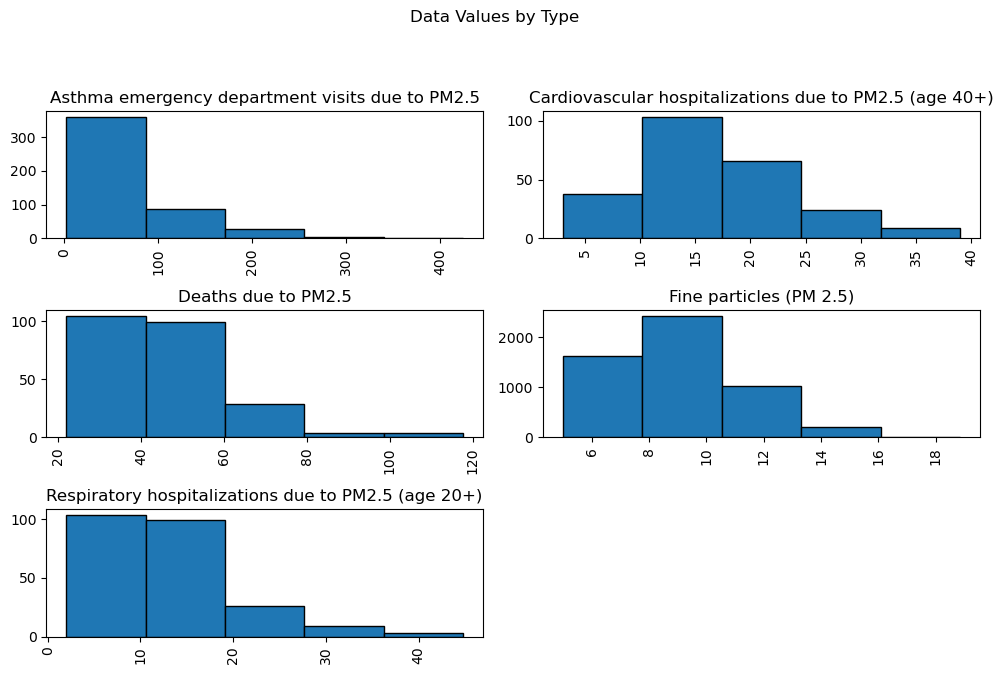

In [14]:
#make histogram to check for outliers 

#y axis is value counts, x is Data Value 

pm25_all.hist(column='Data Value', by='Name', bins=5, edgecolor='black', figsize=(10, 18), layout=(9,2))  

plt.suptitle("Data Values by Type", y=1.02)  

plt.subplots_adjust(hspace=0.8, wspace=0.4) 

plt.tight_layout() 

plt.show() 

In [15]:
pm25_pivot = pm25_all.pivot_table( index=['Geo Place Name', 'Time Period'], columns='Name', values='Data Value' ) 
pm25_pivot.columns = pm25_pivot2.columns.str.strip() 
pm25_pivot

NameError: name 'pm25_pivot2' is not defined

In [ ]:
#whisker box plot 

plt.figure(figsize=(6, 2)) 
sns.boxplot(data=asthma_df, x='Data Value', linewidth=0.9) 

plt.show() 

In [ ]:
sns.scatterplot(data = asthma_df, x = 'Data Value', 

                y = 'Time Period'); 

In [ ]:
#scatter plot - asthma ER vs pm2.5 levels

asthma_df2 = asthma_df.rename(columns={"Data Value": "asthma_er_visits"})  

pm_df2 = pm_df.rename(columns={"Data Value": "pm25_levels"})  



merged_df = pd.merge(asthma_df2, pm_df2, on="Geo Place Name")  


plt.figure(figsize=(8, 6)) 
sns.scatterplot(data=merged_df, x="pm25_levels", y="asthma_er_visits") 



plt.title("PM2.5 Levels vs. Asthma ER Visits")  

plt.xlabel("PM2.5 Concentration") 
plt.ylabel("Asthma ER Visits")  

plt.grid(True, linestyle="--", alpha=0.7)  

plt.show() 

In [ ]:
asthma = asthma_df['Start_Date'].dt.year 

sns.lineplot(data = asthma_df, x = years, 

       y = 'Data Value', 

       estimator = np.mean); 